<div align="center">

<span style="font-size: 36px; font-weight: bold;">
Detecting Drug Interactions with Machine Learning
</span>

<br><br>

**Luca Giobbi**  

<br>

**Supervisor**
<br>
Dr. Ekaterina Krymova
<br>

**Co-Supervisor**
<br>
Dr. Paraskevi Nousi | Dr. Maxim Samarin

<br>

DAS in Data Science  
ETH Zurich  

<br><br>

May 2026

</div>

In [13]:
import os
import warnings
import logging

import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import display
from sklearn.metrics import precision_recall_curve, roc_curve

from ddi_graph_neural_network.train_model import main
from ddi_graph_neural_network.config import LossType
from report_utils import (
    plot_experiment_results,
    render_interactive_visualization,
    get_base_config,
    get_feature_experiment_config,
    compute_node_metrics,
    compile_embeddings,
    plot_pharma_class_error_rates,
    render_model_architecture,
    display_training_set_configurations,
)

In [14]:
warnings.simplefilter(action="ignore", category=FutureWarning)
logging.basicConfig(level=logging.WARNING, format="%(asctime)s - %(levelname)s - %(message)s")

pd.set_option("display.max_rows", 100)
pd.set_option("display.max_columns", 50)
pd.set_option("display.float_format", lambda x: f"{x:.4f}")
sns.set_style("whitegrid")
sns.set_context("talk")
os.environ.update({k: "1" for k in ["OMP_NUM_THREADS", "OPENBLAS_NUM_THREADS", "MKL_NUM_THREADS"]})

# Introduction

Drug-drug interactions (DDIs) occur when the intended effect of one drug is modified by the co-administration of another. With the increasing prevalence of polypharmacy—especially among elderly populations managing multiple prescriptions—DDIs have become a formidable challenge in clinical pharmacology. These interactions can alter absorption, distribution, metabolism, and excretion (pharmacokinetics) or modify tissue responsiveness (pharmacodynamics), frequently resulting in unexpected Adverse Drug Reactions (ADRs). Consequently, DDIs are a major driver of elevated healthcare costs, emergency room visits, and prolonged hospitalizations.

Traditionally, identifying DDIs relied heavily on *in vivo* and *in vitro* laboratory research or premarketing clinical trials. However, these conventional approaches are expensive, time-consuming, and constrained by small sample sizes and brief exposure periods. Consequently, many interactions and critical safety issues often go unnoticed until post-marketing surveillance and wider population exposure. To overcome these limitations, the scientific community has increasingly turned to computational methods. By representing known DDIs accumulated in large biomedical databases, machine learning models can efficiently predict novel, unobserved interactions, serving as highly scalable early-warning systems in pharmacovigilance [[qiu2022_ddi]](#qiu2022_ddi).

This report evaluates a modern machine learning architecture to detect clinically relevant DDIs. We formulate DDI detection as a link prediction task on a unified knowledge graph representing known drug interactions. To move beyond relying solely on structural graph topology, we enrich our network with semantic pharmacological knowledge. Specifically, we utilize dense, continuous text embeddings—generated by a Large Language Model (LLM) from unstructured clinical descriptions—as initial node attributes. Processed through a Graph Convolutional Network (GCN) encoder and trained with a dynamically weighted cross-entropy loss to handle acute class imbalances, we investigate how incorporating this unstructured linguistic knowledge enhances the structural DDI prediction task and facilitates deeper therapeutic insights.

# Materials and Methods

### Dataset


#### Graph

Our empirical evaluation relies on a robust and unified reference dataset that merges large-scale graph representations of drug knowledge with clinically validated interaction endpoints. To construct this benchmark, we integrated data from two primary resources: the ChCh-Miner network and the CRESCENDDI reference set.

**ChCh-Miner Network**  
The ChCh-Miner dataset is a curated drug-drug interaction (DDI) network originally derived from the DrugBank database and built using the MINER parser. It is represented as an undirected graph where nodes correspond to distinct pharmaceutical compounds and edges indicate documented interactions based on drug labels and scientific literature. During the initial data curation, entries with malformed or legacy SMILES strings—such as those containing invalid characters or outdated encodings—were removed to guarantee valid molecular abstractions. The resulting graph is densely connected, comprising 1,514 nodes and 48,514 edges. The dataset exhibits strong local clustering, with a clustering coefficient of 0.30, and the largest strongly connected component encompasses nearly the entire network (1,510 nodes and 48,512 edges) [[chchminer]](#chchminer).

**CRESCENDDI Reference Set**  
The Clinically-relevant REference Set CENtered around Drug-Drug Interactions (CRESCENDDI) provides a gold-standard benchmark created specifically to evaluate signal detection algorithms in pharmacovigilance. The complete resource aggregates 10,286 positive controls and 4,544 negative controls, spanning 454 unique drug ingredients and 179 distinct adverse events standardly mapped to RxNorm and MedDRA terminologies.

To maximize clinical confidence, positive controls in CRESCENDDI were formulated through a strict intersection of three primary compendia: the British National Formulary (BNF), the French National Drug Safety Institute (ANSM) Thesaurus, and Micromedex. Following the normalization of pharmaceutical entities to RxNorm ingredient levels via OHDSI Usagi, the interaction descriptions underwent a blinding procedure where specific drug names were masked using generic tokens. A defining characteristic of this curation was the deliberate focus on empirical clinical manifestations (e.g., elevated risk of an adverse reaction), intentionally excluding entries that merely hypothesized pharmacological mechanisms.

Conversely, the negative control set was generated to rigorously minimize structural and reporting bias. Candidate negative pairs were constructed by randomly combining drugs and adverse events drawn from the existing control pool. Each candidate drug-drug-event triplet was then subjected to a custom automated PubMed query; only triplets yielding identically zero results in the scientific literature were retained. The final size of the negative control set was statistically calibrated to match the subset of positive controls demonstrating non-zero report frequencies in the FDA Adverse Event Reporting System (FAERS) [[crescenddi]](#crescenddi).

**Data Integration and Harmonization**  
To assemble the target graph for our predictive model, we extracted the direct intersection of the ChCh-Miner graph and the clinically robust CRESCENDDI reference set. This union required systematically mapping drug terminology into a shared vector space. Alignment was resolved through a cascading, case-insensitive string mapping technique: a primary mapping phase matched the standardized drug concept name (`DRUG_CONCEPT_NAME`) to the DrugBank text embedding dictionary, followed by a secondary fallback match using the initially reported drug name (`DRUG_INITIAL_NAME`) for any remaining unmapped rows.

From an original pool of 14,830 paired assertions, 414 edges were excluded because their constituents could not be confidently mapped to a DrugBank identifier. Because the interaction relationships are mathematically symmetric, all pairs were subsequently canonicalized by sorting the drug identifiers and removing redundancies. This deduplication process successfully eliminated 5,625 redundant edge expressions out of the intermediate 14,416 edges. 

Finally, strict collision resolution was applied: any negative controls proposed by CRESCENDDI that coincidentally existed as positive, confirmed interactions in the ChCh-Miner network were aggressively pruned. The conclusion of this extensive filtering and harmonization pipeline yielded a finalized, internally consistent reference graph composed of exactly 8,791 unique drug-drug interactions.

#### Node Features and Embeddings

To enrich the structural interaction data with robust semantic, biochemical, and clinical context, we incorporate dense text embeddings as initial node features ($\mathbf{x}_v$) within our graph model. 

Brief, domain-specific textual descriptions for each pharmaceutical compound were originally sourced from the DrugBank database [[drugbank]](#drugbank). For our empirical pipeline, we directly utilized the curated textual preparations publicly provided by the DDI-LLM framework [[ddillm]](#ddillm). 

These variable-length qualitative descriptions were computationally mapped into a continuous, fixed-dimensional real coordinate space using OpenAI's `text-embedding-ada-002` model [[openai_ada]](#openai_ada). Such text embeddings explicitly encode semantic relationships geometrically, guaranteeing that biologically or chemically related drugs occupy proximate regions within the embedding space. This structure subsequently enables reliable nearest-neighbor retrieval and quantitative comparisons typically evaluated via cosine similarity. Off-the-shelf embeddings constructed by large language models have been demonstrably shown to capture transferable semantic structure highly beneficial as functional priors for downstream graph learning tasks [[text_embeddings]](#text_embeddings). 

By supplying these rich semantic vectors as the initial node attributes to the Graph Convolutional Network—substituting a naive baseline of non-informative, constant features (vectors entirely consisting of ones)—the architecture leverages powerful functional priors that substantially promote feature generalizability and sample efficiency in solving the link prediction task.

#### ATC Classification

To effectively analyze model error rates and categorize drug properties across broader therapeutic and chemical boundaries, we incorporate the Anatomical Therapeutic Chemical (ATC) classification system.

**System Structure**
Developed by the WHO, the ATC system hierarchically stratifies active pharmaceutical substances based on the specific organ or system upon which they act, as well as their therapeutic, pharmacological, and chemical properties. The classification comprises five discrete levels:
1. **1st level:** Represents the main anatomical or pharmacological group (fourteen main groups).
2. **2nd level:** Identifies the main pharmacological or therapeutic subgroup.
3. **3rd and 4th levels:** Further specify the chemical, pharmacological, or therapeutic subgroups, frequently utilized when main therapeutic indications span several areas.
4. **5th level:** Specifies the precise chemical substance itself, preferentially using the International Nonproprietary Name (INN).

**Classification Principles and Challenges**
Medicinal substances are primarily assigned a single, unique ATC code determined by their principal therapeutic use globally—which typically relies on route of administration and dosage strength. Higher-level groupings intentionally accommodate drugs possessing multiple therapeutic applications without strictly specifying one single indication (e.g., classifying a drug as a calcium channel blocker without arbitrarily declaring it exclusively for coronary disease). 

Classification challenges generally arise when a compound is equally utilized for multiple disparate primary indications or when standard therapeutic use varies significantly by region. In such instances, the WHO designates a single governing code based on global prevalence, which can occasionally complicate dataset interpretations locally and epidemiologically. Identifying model prediction dependencies across varied ATC classifications forms a critical part of determining structural evaluation biases in our resulting analysis [[who_atc]](#who_atc).

**Integration into the Reference Graph**
To facilitate our downstream error analysis, ATC classifications were integrated into our interaction graph. Because the source datasets lack a unified identifier, the linkage was performed using exact string matching on the drug names. Through this procedure, we successfully mapped the vast majority of the network; however, 176 out of the 1,510 compounds could not be uniquely assigned an ATC class. These unmatched cases are primarily attributable to minor naming discrepancies, missing registry values, or inconsistent formatting of composite nomenclature.

### Model Architecture

We formulate drug-drug interaction (DDI) prediction as a link prediction task on an undirected, homogeneous graph $\mathcal{G} = (\mathcal{V}, \mathcal{E})$, where vertices $v \in \mathcal{V}$ represent individual drugs and edges $e_{u,v} \in \mathcal{E}$ denote validated interactions. Each node $v$ is initialized with a feature vector $\mathbf{x}_v \in \mathbb{R}^d$, representing either dense pre-trained language model embeddings extracted from drug descriptions or a constant baseline vector.

Our architecture employs an encoder-decoder framework. The encoder utilizes a Graph Convolutional Network (GCN) to project node features into a rich, topology-aware latent space, while the decoder computes the pairwise probability of an edge existing between any two nodes.

#### 1. Graph Convolutional Encoder
The encoder learns structural node representations by recursively aggregating features from local neighborhoods. We stack three graph convolutional layers. The propagation rule for the $l$-th layer is defined as:

$$
\mathbf{H}^{(l+1)} = \text{ReLU} \left( \tilde{\mathbf{D}}^{-\frac{1}{2}} \tilde{\mathbf{A}} \tilde{\mathbf{D}}^{-\frac{1}{2}} \mathbf{H}^{(l)} \mathbf{W}^{(l)} \right)
$$

where:
- $\tilde{\mathbf{A}} = \mathbf{A} + \mathbf{I}$ is the adjacency matrix with added self-loops.
- $\tilde{\mathbf{D}}$ is the corresponding degree matrix defined by $\tilde{D}_{ii} = \sum_j \tilde{A}_{ij}$.
- $\mathbf{H}^{(l)}$ is the matrix of hidden node representations at layer $l$, with $\mathbf{H}^{(0)} = \mathbf{X}$.
- $\mathbf{W}^{(l)}$ is the layer-specific trainable weight matrix.

**Network Configuration:** 
The network consists of three layers. The first layer projects the initial $d$-dimensional input features into a 256-dimensional hidden space. The second and third layers maintain this 256-dimensional representation. To introduce non-linearity and combat severe overfitting, we apply a Rectified Linear Unit (ReLU) and Dropout regularization (with rate $p=0.3$) after the first and second convolutional operations. The final layer emits the encoded vertex embeddings $\mathbf{z}_v \in \mathbb{R}^{256}$ without additional non-linear activations.

#### 2. Pairwise Dot-Product Decoder
To predict the absence or presence of an interaction between two drugs $u$ and $v$, the decoder acts directly on the learned latent representations $\mathbf{z}_u$ and $\mathbf{z}_v$. We employ a symmetric inner-product (dot-product) decoder to model the structural similarity in the embedded space:

$$
\hat{s}_{u,v} = \mathbf{z}_u^\top \mathbf{z}_v
$$

The scalar output $\hat{s}_{u,v}$ serves as the unnormalized predicted logit representing the log-odds of an interaction edge. During inference, these logits are mapped to valid probabilities via the standard logistic sigmoid function $\hat{y}_{u,v} = \sigma(\hat{s}_{u,v})$.

#### 3. Optimization and Training Dynamics
The model is trained entirely end-to-end to correctly classify true drug-drug interactions (positive edges) against non-interacting pairs (negative edges).

**Loss Function:** 
We explicitly counteract the severe class imbalance inherent to drug interaction graphs using a weighted binary cross-entropy (BCE) loss. Let $p=\sigma(z)$ be the model probability (sigmoid of the logit $z$), $y\in\{0,1\}$ the true label, and $N_{pos},N_{neg}$ the counts of positive and negative examples used for training. We define a positive‑class scaling factor:

$$
\alpha_{pos} = \mathrm{pos\_loss\_multiplier}\;\frac{N_{neg}}{N_{pos}},
$$

and set the negative weight to $\alpha_{neg}=1$. The per‑example weighted binary cross‑entropy is computed as:

$$
\mathcal{L}(p,y) = -\alpha_{pos}\,y\,\log p - \alpha_{neg}\,(1-y)\,\log(1-p).
$$

In PyTorch, this is computationally achieved by providing a `pos_weight` parameter to `BCEWithLogitsLoss` (equal to $\alpha_{pos}$ above), explicitly scaling the positive class's contribution based on the empirical ratio and optimal scalar adjustment.

*Note on Focal Loss:* The binary focal loss modifies cross‑entropy with a focusing term, defined as $\mathrm{FL}(p_t) = -\alpha\,(1-p_t)^{\gamma}\,\log(p_t)$, where $\gamma\ge 0$ focuses training on difficult examples. During hyperparameter search, we observed the optimal focal parameter gracefully collapsed to $\gamma\approx 0$ (reducing the formula back to standard weighted BCE). Hence, focal loss provided no empirical advantage over standard weighted BCE for this graph topology.

**Training Regimen:** 
Stochastic gradient descent is performed via the Adam optimizer using an initial learning rate decay scheduled via a MultiplicativeLR modifier. To enforce generalization and prevent topological memorization, we monitor the Receiver Operating Characteristic Area Under the Curve (ROC-AUC) on a held-out validation set at each epoch. The training loop employs an early stopping mechanism with a configured patience threshold on the validation ROC-AUC to isolate and retain the optimal model parameter state of the model parameters.

In [6]:
render_model_architecture()

# Experiments and Results

## Experiments on Loss Functions and Labels

This section outlines how negative, non-interacting examples are empirically constructed during the training phase, alongside the specific hyperparameters evaluated for handling dataset imbalance.

**Negatives for training**

- **Sampled negatives:** Unlabeled pairs (non‑positive edges) are sampled uniformly and treated as negatives for training. This baseline approach assumes most unobserved pairs in a sparse graph are true negatives, but openly admits the risk of including unlabelled positives among the sampled edges.
- **Observed (validated) negatives:** Use solely the formally validated negative labels provided directly by the CRESCENDDI dataset queries. This yields a much smaller negative set; to correct for the resulting acute class imbalance, we compensate entirely by weighting the final cross-entropy loss rather than physically inflating the negative sample count.
- **Upsampled negatives:** Augment the available observed negatives through random uniform sampling with replacement, enforcing that the number of negative training examples perfectly matches the number of positive examples in the batch. While this forces a mathematically balanced training set, it naturally alters the effective data distribution seen during training parameter optimization.

**Experimental design**

To strictly establish the optimal model configuration, we run an exhaustive search over combinations of the following three design paradigms. Please note that across all variations tested below, we standardly incorporate GPT-3 derived drug description embeddings as the initial node features (as evaluated later).

1. **Loss function weighting:** Either (a) utilizing plain, unweighted binary cross‑entropy on logits (`BCEWithLogitsLoss`), treating positive and negative assertions with equal static importance, or (b) employing a dynamically weighted cross-entropy explicitly scaled via a predetermined parameter multiplier.
2. **Negative handling methodology:** Whether training negatives are artificially upsampled via sampling with replacement to mirror positive counts, or whether the model exclusively sees uniquely sampled subsets corresponding to original empirical ratios.
3. **Training negative selection strategy:** Whether the training logic strictly utilizes sampled negatives (random pulls from the generalized unlabeled pool) or if it explicitly utilizes the highly curated, validated negatives governed by `use_only_sampled_negatives_in_train`.

### Optimizing individual losses

In [2]:
settings = [
    {
        "loss_type": LossType.BCEWithLogitsLoss,
        "pos_loss_multiplier": 1,
        "upsample_negative_labels": True,
        "use_only_sampled_negatives_in_train": False,
    },
    {
        "loss_type": LossType.BCEWithLogitsLoss,
        "pos_loss_multiplier": 1,
        "upsample_negative_labels": True,
        "use_only_sampled_negatives_in_train": True,
    },
    {
        "loss_type": LossType.WeightedBCEWithLogitsLoss,
        "pos_loss_multiplier": 0.5,
        "upsample_negative_labels": True,
        "use_only_sampled_negatives_in_train": False,
    },
    {
        "loss_type": LossType.WeightedBCEWithLogitsLoss,
        "pos_loss_multiplier": 0.5,
        "upsample_negative_labels": True,
        "use_only_sampled_negatives_in_train": True,
    },
    {
        "loss_type": LossType.WeightedBCEWithLogitsLoss,
        "pos_loss_multiplier": 0.5,
        "upsample_negative_labels": False,
        "use_only_sampled_negatives_in_train": False,
    },
    {
        "loss_type": LossType.WeightedBCEWithLogitsLoss,
        "pos_loss_multiplier": 0.5,
        "upsample_negative_labels": False,
        "use_only_sampled_negatives_in_train": True,
    },
]


In [4]:
results_list = []
for i, setting in enumerate(settings):
    # Fetch a fresh base config for each run to avoid side-effects
    config = get_base_config()
    config.run.loss_type = setting["loss_type"]
    config.run.pos_loss_multiplier = setting["pos_loss_multiplier"]
    config.run.upsample_negative_labels = setting.get("upsample_negative_labels", False)
    config.run.use_only_sampled_negatives_in_train = setting.get("use_only_sampled_negatives_in_train", False)

    name = f"{setting['loss_type'].name}|mult={setting['pos_loss_multiplier']}|ups={setting.get('upsample_negative_labels', False)}|only_sampled={setting.get('use_only_sampled_negatives_in_train', False)}|reps={config.training.repetitions}"
    print(f"=== Running [{i + 1}/{len(settings)}]: {name} ===")

    run = main(config)
    y_true, y_scores = np.asarray(run["label"]), np.asarray(run["test_scores"])
    precision, recall, _ = precision_recall_curve(y_true, y_scores)
    fpr, tpr, _ = roc_curve(y_true, y_scores)

    results_list.append(
        {"name": name, "metrics": run["metrics"], "precision": precision, "recall": recall, "fpr": fpr, "tpr": tpr}
    )

settings_results = results_list

=== Running [1/6]: BCEWithLogitsLoss|mult=1|ups=True|only_sampled=False|reps=1 ===
======== DESC_GPT ========


KeyboardInterrupt: 

In [ ]:
_ = display_training_set_configurations(settings)

### Training Set Configurations

|    | Loss Function             |   Observed Positives in Train |   Observed Negatives in Train |   Sampled Negatives in Train |   Weight Factor Negative Loss |
|:---|:--------------------------|------------------------------:|------------------------------:|-----------------------------:|------------------------------:|
| S1 | BCEWithLogitsLoss         |                         30066 |                          2272 |                        27794 |                        1      |
| S2 | BCEWithLogitsLoss         |                         30066 |                             0 |                        30066 |                        1      |
| S3 | WeightedBCEWithLogitsLoss |                         30066 |                          2272 |                        27794 |                        2      |
| S4 | WeightedBCEWithLogitsLoss |                         30066 |                             0 |                        30066 |                        2      |
| S5 | WeightedBCEWithLogitsLoss |                         30066 |                          2272 |                            0 |                       26.4665 |
| S6 | WeightedBCEWithLogitsLoss |                         30066 |                             0 |                         2272 |                       26.4665 |

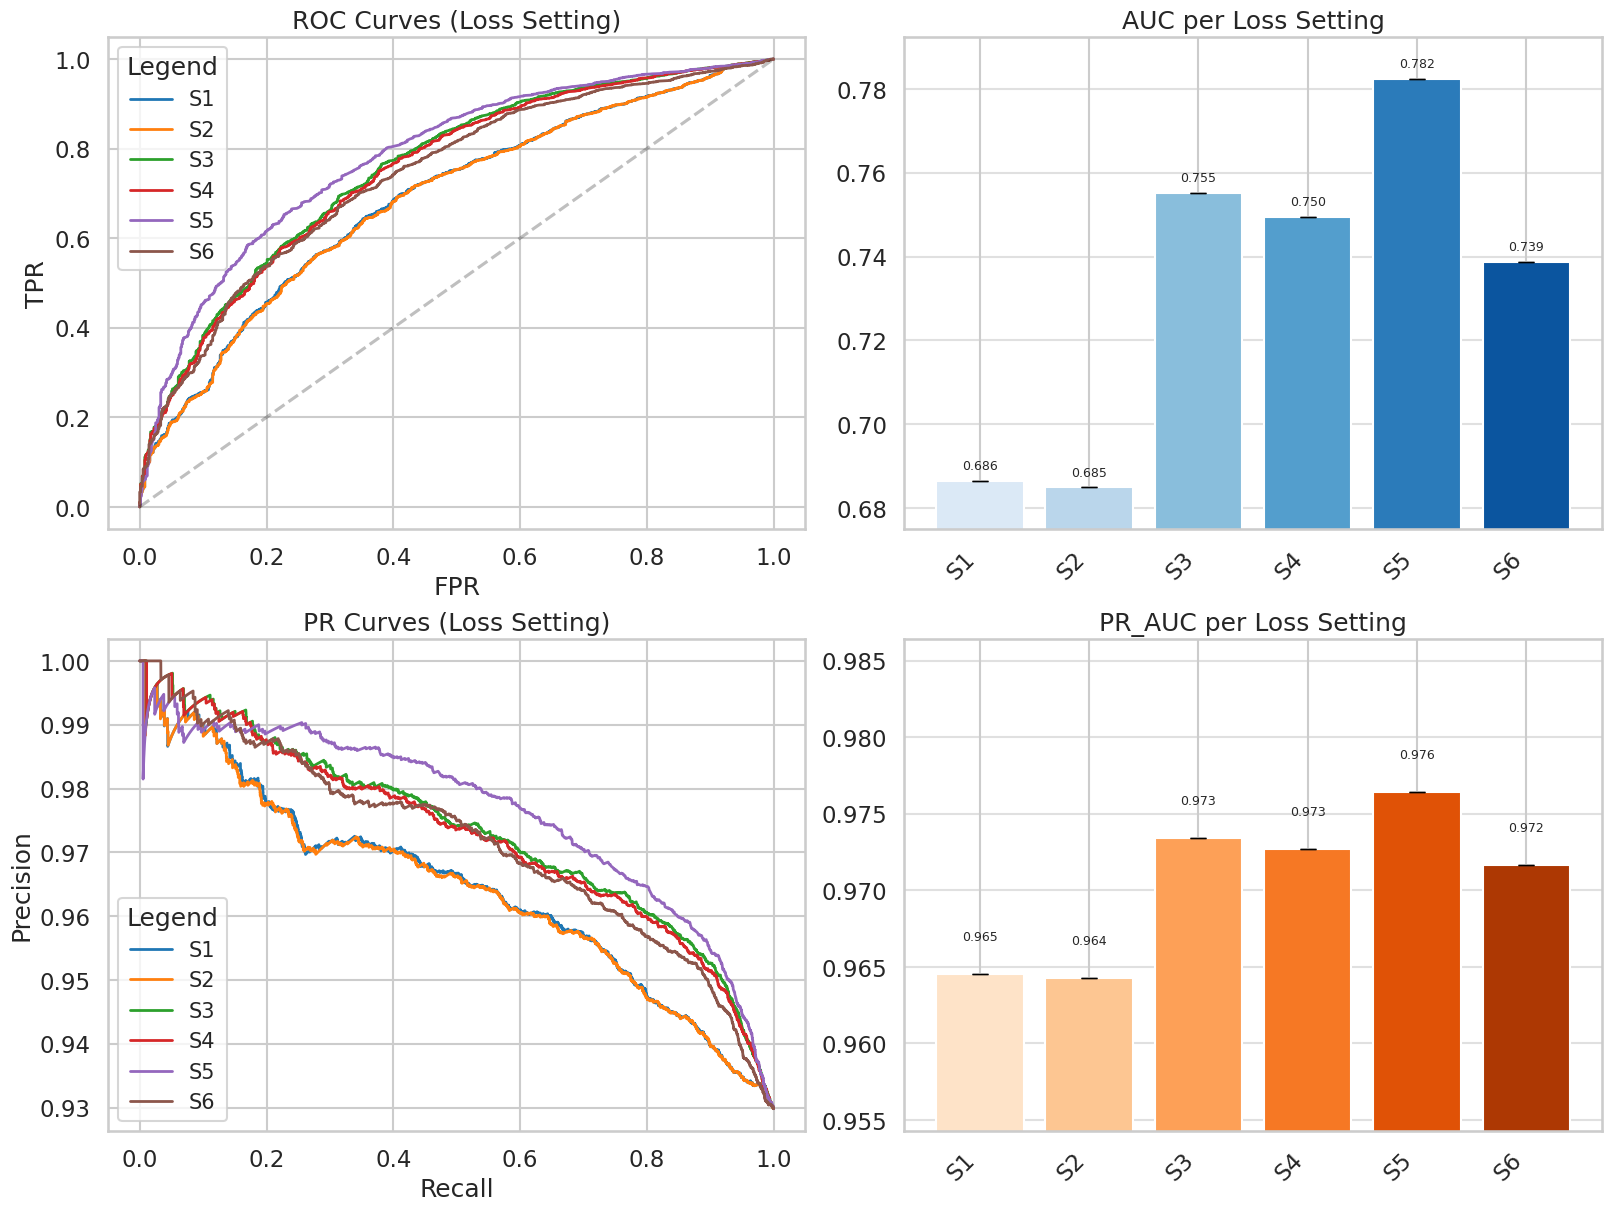

### Summary of Metrics (Loss Setting)

| short name   |   AUC_mean |   AUC_std |   PR_AUC_mean |   PR_AUC_std |
|:-------------|-----------:|----------:|--------------:|-------------:|
| S1           |   0.686494 |         0 |      0.96456  |            0 |
| S2           |   0.684963 |         0 |      0.96428  |            0 |
| S3           |   0.755235 |         0 |      0.973413 |            0 |
| S4           |   0.74951  |         0 |      0.972702 |            0 |
| S5           |   0.782446 |         0 |      0.976445 |            0 |
| S6           |   0.738674 |         0 |      0.971664 |            0 |

In [8]:
# Generate plots and metrics output for the Loss Settings
plot_experiment_results(settings_results, title_suffix="Loss Setting", filename="report_grid.png")

### Summary of Empirical Findings

Across all experimental settings, reducing the positive loss multiplier—specifically downweighting it to $0.5$ relative to the balanced ratio $N_{neg} / N_{pos}$—consistently improved performance compared to using the standard unweighted Binary Cross-Entropy (BCE) loss. 

Furthermore, including the true observed negative labels as a learning signal improved overall performance more than uniformly sampling negatives. Relying exclusively on these true negatives, while addressing the resulting class imbalance through a weighted loss function, yielded the strongest predictive performance. This suggests that the validated, true negative pairs provide a significantly more informative learning signal.

In contrast, upsampling negatives to artificially enforce class balance did not confer any advantage and, in some settings, even degraded validation metrics. Therefore, preserving the real empirical negative distribution and adjusting for imbalance via the loss function proved to be the most effective strategy for model generalization in our experiments.

## Evaluating Node Feature Representations

### LLM Embeddings vs. Baseline Initialization

As detailed in the Preliminary data section, we systematically evaluate the functional contribution of the semantic node features to the overall prediction model. In evaluating the performance of these text embeddings within our Graph Convolutional Network (GCN), we empirically benchmark substituting a baseline, non-informative feature strategy (an initial node feature vector uniformly initialized to ones, denoted as `__ONES__`) with the dense, domain-focused LLM-derived features generated via OpenAI's ADA model (`DESC_GPT`). 

Throughout these downstream experimental evaluations, all auxiliary components of the learning pipeline—including the training/test splits, optimal weighted BCE loss configuration, network architectural sizes, and all associated training hyperparameters—were held strictly constant. By keeping the underlying topological processing and optimization framework entirely frozen, any resulting variance precisely isolates the true classification capability gain, allowing improvements in validation metrics (such as ROC-AUC and PR-AUC) to be explicitly attributed to the underlying semantic knowledge captured by the embedded structural representations.

In [2]:
feature_settings = [
    {
        "feature": "__ONES__",
    },
    {
        "feature": "DESC_GPT",
    },
]

In [3]:
feature_results = []
for i, setting in enumerate(feature_settings):
    feature = setting.get("feature")
    # Use the isolated config definition for feature evaluation
    config_feature = get_feature_experiment_config()
    config_feature.graph.feature = feature

    name = f"Feature|{feature}"
    print(f"=== Running [{i + 1}/{len(feature_settings)}]: {name} ===")

    run = main(config_feature)
    y_true, y_scores = np.asarray(run["label"]), np.asarray(run["test_scores"])
    precision, recall, _ = precision_recall_curve(y_true, y_scores)
    fpr, tpr, _ = roc_curve(y_true, y_scores)

    feature_results.append(
        {"name": name, "metrics": run["metrics"], "precision": precision, "recall": recall, "fpr": fpr, "tpr": tpr}
    )

=== Running [1/2]: Feature|__ONES__ ===
======== __ONES__ ========
-------------------------------
-- FINAL RESULTS FOR GRAPH DrugBank_CRESCENDDI | FEATURE __ONES__ -- 
Graph Data:  DrugBank_CRESCENDDI
ROC_AUC: 0.6597
PR_AUC: 0.9611
=== Running [2/2]: Feature|DESC_GPT ===
======== DESC_GPT ========
-------------------------------
-- FINAL RESULTS FOR GRAPH DrugBank_CRESCENDDI | FEATURE DESC_GPT -- 
Graph Data:  DrugBank_CRESCENDDI
ROC_AUC: 0.7824
PR_AUC: 0.9764


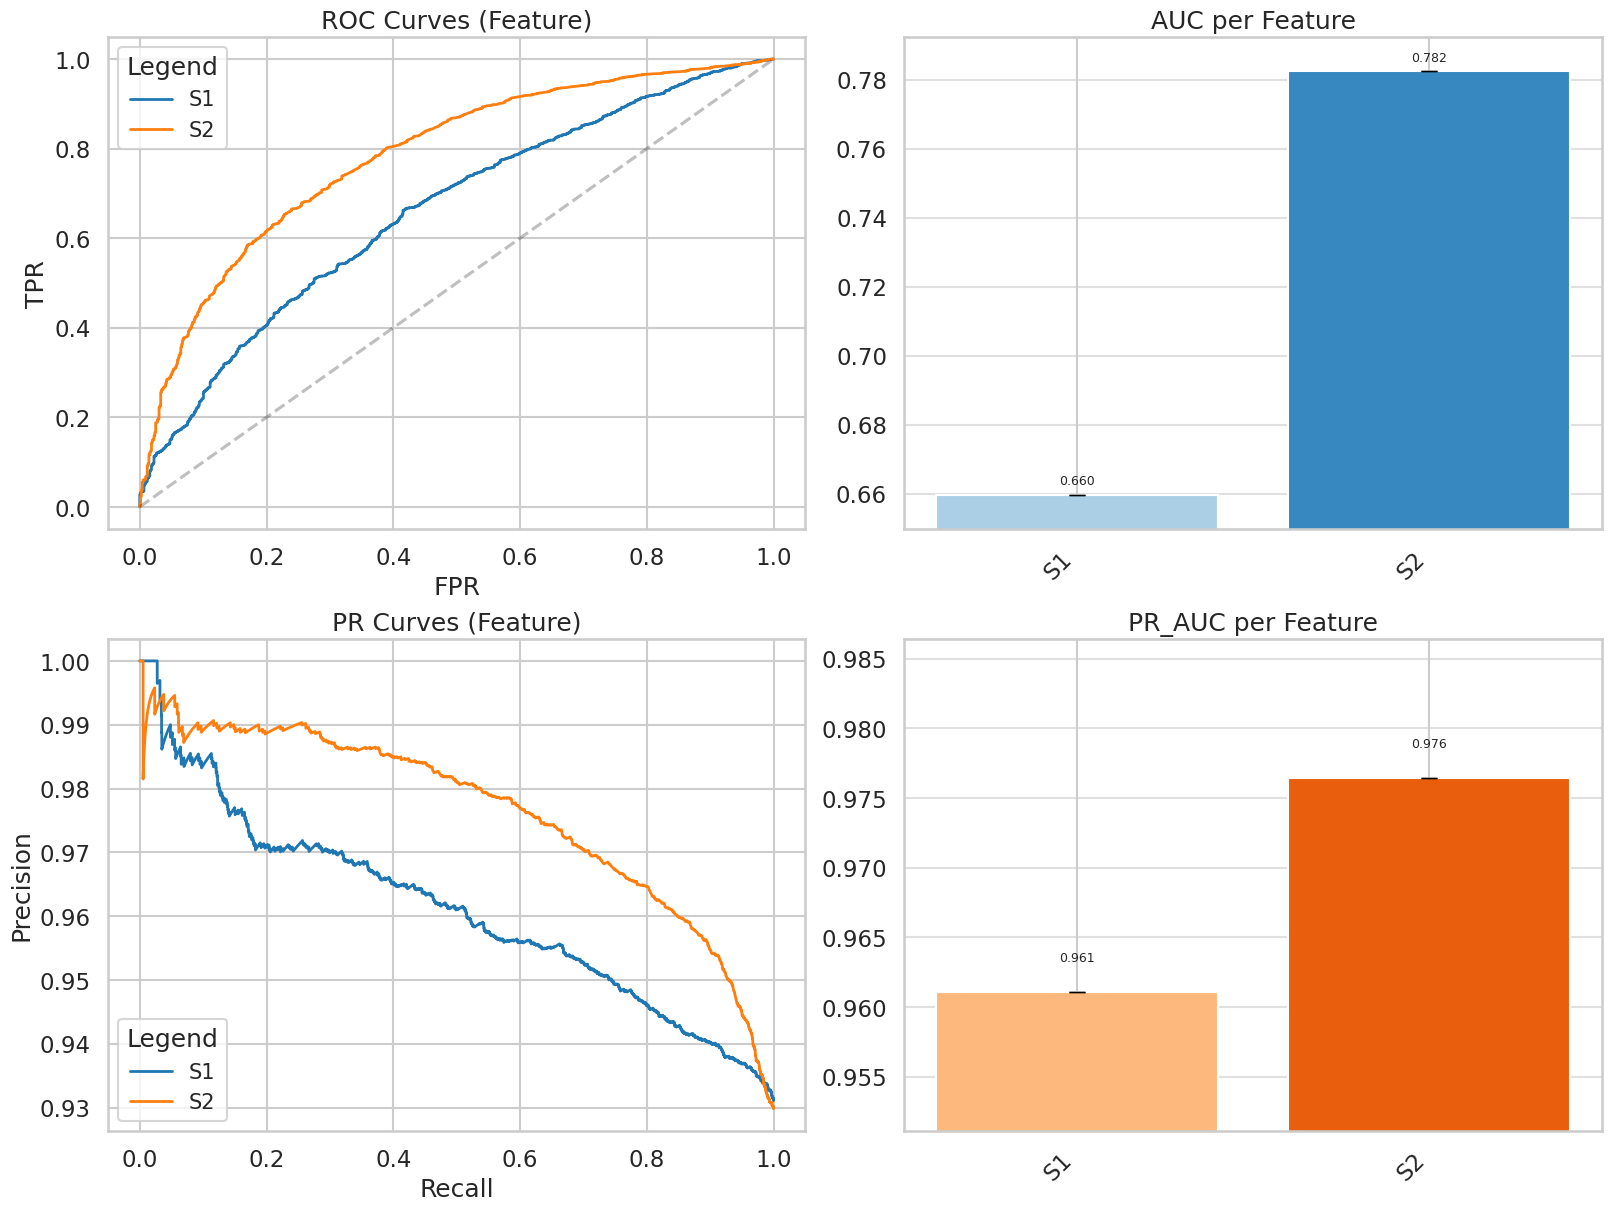

### Summary of Metrics (Feature)

| short name   |   AUC_mean |   AUC_std |   PR_AUC_mean |   PR_AUC_std |
|:-------------|-----------:|----------:|--------------:|-------------:|
| S1           |   0.659729 |         0 |      0.961097 |            0 |
| S2           |   0.782446 |         0 |      0.976445 |            0 |

In [4]:
# Generate plots and metrics output for the Embeddings Settings
plot_experiment_results(feature_results, title_suffix="Feature", filename="report_grid_features.png")

We see a strong improvement of the learning signal when including the description embeddings as features.

On the area under curve in the receiver operating characteristic, we see a strong improvement, meaning the model improved drastically in separating positive (drug interaction) examples from negative examples across all classification thresholds.

The precision-recall AUC also improved significantly, showing that the model achieves better precision-recall trade-offs when predicting drug interactions—a critical metric for imbalanced datasets where positive interactions are more prevalent than negatives. This improvement indicates the embeddings provide semantic information about drug properties that the model leverages to reduce false positives while maintaining high recall for true interactions.

## Final Model Evaluation

In the following section, we analyze our model's performance in its optimal configuration, employing GPT-3 embeddings of drug descriptions combined with weighted binary cross-entropy loss (weight factor on negative loss = 26.4665) and no upsampling of negative labels. To ensure fair comparison across experimental settings, we calibrate the prediction threshold such that the number of predicted positive and negative labels are balanced.

Description embeddings prove to be a critical learning signal, yielding substantial improvements in model performance: the ROC-AUC increases from 0.66 to 0.78, and the PR-AUC improves from 0.96 to 0.98 compared to the baseline with constant node features. To elucidate the mechanisms underlying this improvement, we conducted a series of exploratory analyses presented below. Further ablation studies are required to fully characterize the contributions of individual components and to validate the statistical significance of our findings.

In [3]:
# Run the model using the analysis config
config_analysis = get_feature_experiment_config()
config_analysis.graph.feature = "DESC_GPT"

run = main(config_analysis)

# Unpack run results
test_data, test_scores, data, model = run["test_data"], run["test_scores"], run["data"], run["model"]
reversed_node_id_map = {v: k for k, v in run["node_id_map"].items()}

======== DESC_GPT ========
-------------------------------
-- FINAL RESULTS FOR GRAPH DrugBank_CRESCENDDI | FEATURE DESC_GPT -- 
Graph Data:  DrugBank_CRESCENDDI
ROC_AUC: 0.7824
PR_AUC: 0.9764


In [15]:
# Compute threshold and mapped predictions, and aggregate classification counts across all connected edges per source
threshold, node_info_trained = compute_node_metrics(test_data, test_scores, reversed_node_id_map)

# Extract spatial and feature embeddings, resolve ATC classes and compile into a single dataframe
embedding = compile_embeddings(model, data, reversed_node_id_map, node_info_trained)


print(f"Threshold: {threshold:.4f} | Negatives: {node_info_trained['FN'].sum() + node_info_trained['TN'].sum()}")
# display(node_info_trained.head())
display(embedding.head(3))

NameError: name 'test_data' is not defined

### Results

For each ATC class, we report aggregated performance statistics computed from the test set: the number of drugs per class, median misclassification rate, interquartile range, mean, and standard deviation. The boxplot below visualizes the distribution of these metrics across all therapeutic categories.

,class,n,median,IQR,mean,std
9,NERVOUS SYSTEM DRUGS,248,29.4093,38.3356,38.5599,32.9028
2,ANTINEOPLASTIC AND IMMUNOMODULATING AGENTS,177,64.7059,66.6667,64.2071,34.2902
13,Unknown,176,90.2778,66.6667,67.2695,38.4224
0,ALIMENTARY TRACT AND METABOLISM DRUGS,163,82.7586,57.7381,68.8032,33.6697
5,CARDIOVASCULAR SYSTEM DRUGS,162,61.8056,63.9388,60.6399,31.5134
1,ANTIINFECTIVES FOR SYSTEMIC USE,152,88.8889,58.7500,71.8585,33.0236
11,SENSORY ORGAN DRUGS,115,71.4286,58.2011,64.3044,32.8076
10,RESPIRATORY SYSTEM DRUGS,104,21.5251,62.7493,36.5128,36.8971
6,DERMATOLOGICALS,90,66.6667,66.2162,64.7818,34.1525
7,GENITO URINARY SYSTEM AND SEX HORMONES,79,85.7143,57.7778,71.0995,31.8836


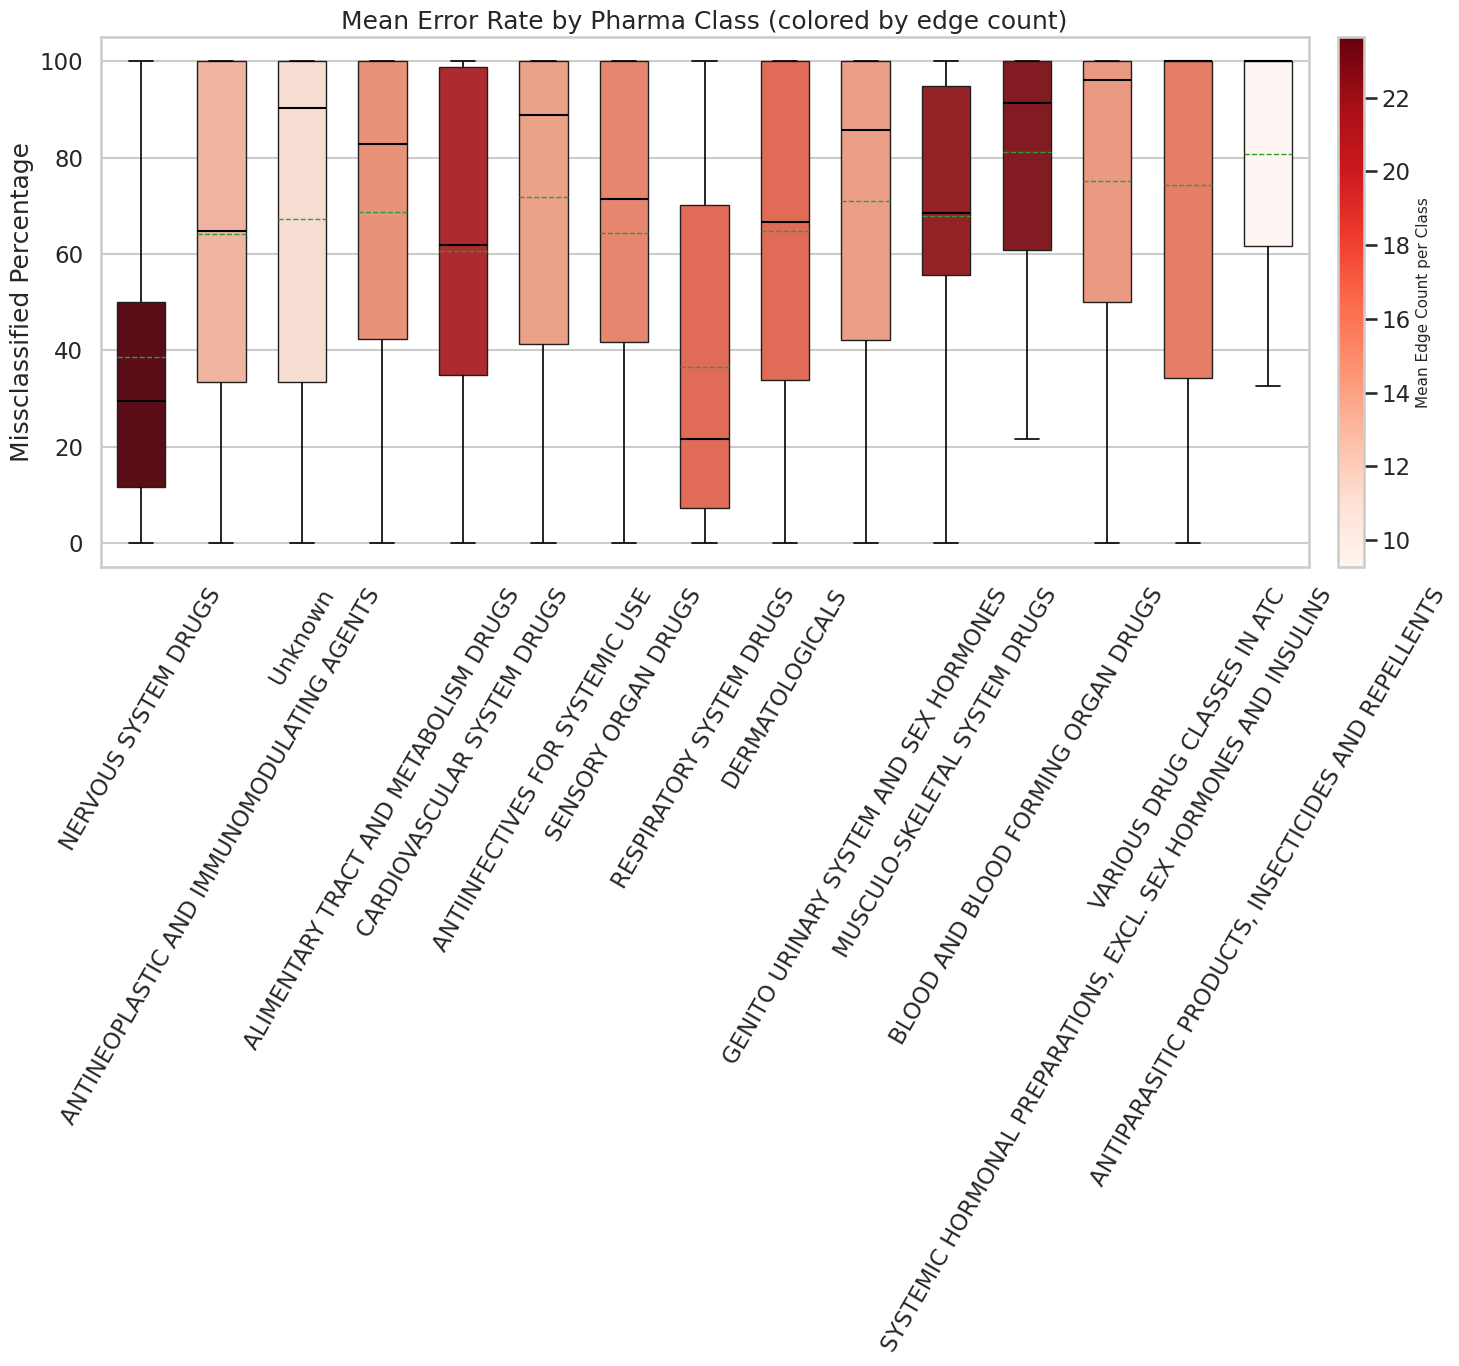

In [5]:
# Summarize error rates by Pharma Class and plot distribution using a Seaborn boxplot
plot_pharma_class_error_rates(embedding)

The per-class misclassification rates across ATC drug classifications reveal interesting performance variations among therapeutic categories. Our analysis presents the median (black), mean (green), and interquartile range of misclassification rates for each ATC class. The visualization shows that drugs targeting the nervous system and respiratory system exhibit notably lower misclassification rates compared to other therapeutic categories. This observation raises an important question about the underlying causes: are these lower error rates inherent to the chemical nature of drug interactions within these classes, or do they result from differences in dataset composition—such as the number of drugs per class, the density of edges, or the distribution of negative labels?

To address this question, we propose several approaches. First, suitable statistical tests could be applied, or the data could be normalized across classes to account for potential sampling biases. Second, since drug class information is implicitly encoded within the drug description embeddings used as node features, it is worth investigating whether these ATC classes constitute an important learning signal for the graph neural network. To evaluate this hypothesis, we suggest replacing the description embeddings with explicit ATC class features and comparing the model's performance. This substitution would allow us to isolate the contribution of class-level information to the model's predictive capacity. Additionally, similar analyses conducted on simpler baseline models would help establish the statistical significance of these findings and whether the observed effects are specific to the graph neural network architecture.

### Visualizations

To elucidate what structural information the model learns from drug descriptions—and how this contributes to its improved predictive performance—we examine the learned representations through a two-dimensional t-SNE projection of embeddings from the test set. We compare two feature spaces: (1) the input space derived directly from drug descriptions using GPT-3 embeddings, and (2) the latent space learned by the graph convolutional network trained on these embeddings. In both projections, clustering patterns are predominantly driven by ATC drug class membership, indicating that therapeutic classification encodes meaningful chemical and biological similarities that inform drug interaction prediction.

The interactive visualization enables detailed exploration of individual drugs and their predicted interactions. By selecting a drug of interest from the dropdown menu, users can examine all edges linking to that drug in the test set, with each edge color-coded according to its classification outcome (true positive, false positive, false negative, or true negative). The visualization further allows filtering by ATC class and edge type, facilitating targeted analysis of model performance across different therapeutic categories.

Each data point in the plot is accompanied by comprehensive metadata, including the drug name, DrugBank identifier, ATC classification, t-SNE coordinates, and the full description text used to generate the initial embeddings. This integrated view supports both qualitative inspection of individual cases and systematic exploration of systematic patterns in model predictions.


In [17]:
# ===== INTERACTIVE VISUALIZATION =====
render_interactive_visualization(embedding, test_data, test_scores, threshold, reversed_node_id_map)

# Discussion

In this study, we evaluated the efficacy of combining Graph Convolutional Networks (GCNs) with Large Language Model (LLM) feature embeddings for the complex task of predicting Drug-Drug Interactions (DDIs). By harmonizing the ChCh-Miner network with the clinically rigorous CRESCENDDI reference set, we established a high-confidence benchmark graph. Our experiments demonstrate that injecting domain-specific textual descriptions—parameterized into dense vectors via OpenAI's `text-embedding-ada-002`—as initial node attributes yields a drastic improvement in predictive accuracy. Compared to a non-informative baseline, the semantically enriched model increased the ROC-AUC from 0.66 to 0.78 and the PR-AUC from 0.96 to 0.98.

**Handling Class Imbalance and Negative Sampling**  
A critical component of our pipeline's success was the optimization of the learning signal amidst severe class imbalance. We found that utilizing the formally validated, empirical negative examples provided by CRESCENDDI, rather than uniformly sampling unlabeled edges or artificially upsampling the minority class, produced the most robust generalization. Mathematically adjusting for this imbalance via a weighted Binary Cross-Entropy (BCE) loss—specifically, reducing the positive loss multiplier to 0.5 relative to the empirical ratio—prevented the model from overly predicting the majority class without corrupting the natural distribution of the training data.

**Representation Learning and Therapeutic Clustering**  
The improvement in classification metrics emphasizes the value of the LLM embeddings as strong functional priors. Our t-SNE visualizations of the learned latent representations confirm that the structural and semantic traits captured by the GCN align closely with established biological taxonomies. Specifically, the latent space naturally clusters nodes largely in accordance with their Anatomical Therapeutic Chemical (ATC) classifications. This reveals that the model successfully learns to encode generalized therapeutic, pharmacological, and chemical similarities purely from unstructured textual knowledge and local graph topology.

**Performance Disparities and Limitations**  
Despite the strong overall performance, our ATC-based error analysis highlighted distinct misclassification disparities among therapeutic boundaries. For example, drugs targeting the nervous and respiratory systems exhibited notably lower misclassification rates. It remains unclear whether this variance stems from the inherent chemical predictability of these interacting compounds or systemic data biases, such as heterogeneous node degrees (i.e., some drug families simply having more documented interactions in the ChCh-Miner corpus). These class-specific performance differences underscore the necessity for continued ablation studies to ensure fair and safe algorithmic deployment in clinical pharmacovigilance.

## Future Work and Open Points

To further validate and enhance the predictive capabilities of the current framework, several critical areas require future investigation:

**1. Interpretability of the Learning Signal**  
A significant open question involves understanding the exact semantic or topological features driving the model's success. As proposed in our error analysis, the core learning signal requires deeper ablation. Specifically, replacing the LLM-derived description embeddings with explicit categorical variables (such as direct ATC class one-hot vectors) will help clarify to what extent the Graph Neural Network simply recovers broad therapeutic categorization versus capturing more profound biochemical relationships. Beyond mere therapeutic classification, it remains to be determined what other latent factors—such as pharmacokinetic properties, target protein affinities, or structural mechanisms implicitly encoded within the unstructured text—are actively contributing to the model's predictive power. 

**2. Enhanced Datasets and Rigorous Evaluation Splits**  
Future iterations should evaluate the architecture on the `ogbl-ddi` dataset from the Open Graph Benchmark [[ogb]](#ogb). This homogeneous, unweighted drug-drug interaction network offers a standardized evaluation protocol ranking true interactions against a massive pool of approximately 100,000 negative samples using the Hits@K metric (typically $K=20$). Crucially, `ogbl-ddi` introduces a *protein-target split*, ensuring that test-set drugs bind to fundamentally different target proteins than those in the training set. This challenging split tests the model's ability to generate practically useful predictions for novel biological mechanisms, overcoming the limitations of traditional random edge splits where similar medications are already present during training [[guney2017]](#guney2017).

**3. Upgrading the Feature Embedding Architecture**  
Our empirical baseline relies on OpenAI's `text-embedding-ada-002` for generating the feature space $\mathbf{x}_v$. However, state-of-the-art embedding models have evolved significantly. Integrating more powerful contemporary representation models, such as Google's Gemini Embedding 2 [[gemini]](#gemini) or OpenAI's text-embedding-3-large [[openai_v3]](#openai_v3), promises higher-resolution semantic mapping. Regenerating the node features with these advanced architectures might reveal finer clustering properties and further improve downstream classification metrics.

# Conclusion

In conclusion, this study demonstrates the substantial value of integrating modern Natural Language Processing (NLP) representations into structural graph representations for drug-drug interaction (DDI) prediction. By augmenting a standard Graph Convolutional Network with dense, LLM-generated semantic features (derived from textual drug descriptions), we observed a significant leap in predictive precision and recall over non-informative baselines. Furthermore, our experiments underscore the critical importance of rigorous negative sampling and proper loss formulation—specifically, that learning from clinically validated negative examples via a carefully scaled Binary Cross-Entropy loss yields models that generalize far better than those trained on uniformly sampled background distributions.

While the model effectively captures complex therapeutic and chemical similarities, as evidenced by our ATC-based error analysis and latent space visual clustering, challenges remain. Performance disparities across different pharmaceutical subgroups suggest that the density of documented interactions and the inherent complexity of certain biological mechanisms can still introduce bias. Moving forward, investigating advanced evaluation splits (e.g., matching the rigor of the `ogbl-ddi` dataset), dissecting the exact biochemical learning signals, and upgrading to state-of-the-art embedding architectures represent the next concrete steps. Ultimately, combining structural topological algorithms with unconstrained textual knowledge represents a powerful and highly promising paradigm for computational pharmacovigilance and automated drug safety screening.

# References

**[qiu2022_ddi]** <span id="qiu2022_ddi">Qiu, Y., Zhang, Y., Deng, Y., Liu, S., and Zhang, W. (2022). "A Comprehensive Review of Computational Methods for Drug-Drug Interaction Detection." *IEEE/ACM Transactions on Computational Biology and Bioinformatics*, vol. 19, no. 4, pp. 1968-1985. [doi: 10.1109/TCBB.2021.3081268](https://ieeexplore.ieee.org/abstract/document/9435097).</span>  
**[chchminer]** <span id="chchminer">Zitnik, M., Agrawal, M., and Leskovec, J. "BioSNAP: Network datasets: Drug-drug interaction network." Stanford Network Analysis Project (SNAP). [URL](https://snap.stanford.edu/biodata/datasets/10001/10001-ChCh-Miner.html).</span>  
**[crescenddi]** <span id="crescenddi">Dumont, F. et al. (2022). "A reference set of clinically relevant adverse drug-drug interactions." *Scientific Data* 9, 219. [URL](https://www.nature.com/articles/s41597-022-01159-y).</span>  
**[drugbank]** <span id="drugbank">DrugBank. "DrugBank Release Version 5.1.9." [URL](https://go.drugbank.com/releases/5-1-9).</span>  
**[ddillm]** <span id="ddillm">Safari, S. et al. "DDI-LLM: Drug-Drug Interaction Prediction: Experimenting With Large Language-Based Drug Information Embedding For Multi-View Representation Learning." GitHub Repository. [URL](https://github.com/sshaghayeghs/DDI-LLM/tree/main).</span>  
**[openai_ada]** <span id="openai_ada">OpenAI. (2022). "New and improved embedding model." [URL](https://openai.com/index/introducing-text-and-code-embeddings/).</span>  
**[text_embeddings]** <span id="text_embeddings">Neelakantan, N. et al. (2022). "Text and Code Embeddings by Contrastive Pre-Training." *arXiv preprint arXiv:2201.10005*. [URL](https://arxiv.org/abs/2201.10005).</span>  
**[who_atc]** <span id="who_atc">World Health Organization. "ATC classification." ATC/DDD Toolkit. [URL](https://www.who.int/tools/atc-ddd-toolkit/atc-classification).</span>  
**[ogb]** <span id="ogb">Hu, W., Fey, M., Zitnik, M., Dong, Y., Ren, H., Liu, B., Catasta, M., and Leskovec, J. (2020). "Open Graph Benchmark: Datasets for Machine Learning on Graphs." *Advances in Neural Information Processing Systems (NeurIPS)* 33. [URL](https://cs.stanford.edu/people/jure/pubs/ogb-neurips20.pdf).</span>  
**[guney2017]** <span id="guney2017">Guney, E. (2017). "Reproducible drug repurposing: When similarity does not suffice." *Pacific Symposium on Biocomputing*, pp. 132–143.</span>  
**[gemini]** <span id="gemini">Google Cloud. "Gemini Embedding 2 | Generative AI on Vertex AI." Google Cloud Documentation. [URL](https://docs.cloud.google.com/vertex-ai/generative-ai/docs/models/gemini/embedding-2).</span>  
**[openai_v3]** <span id="openai_v3">OpenAI. "Text-embedding-3-large." OpenAI API Documentation. [URL](https://developers.openai.com/api/docs/models/text-embedding-3-large).</span>